<h1 align="left">TAREA 2</h1>
El archivo a utilizar es "panel_eps.csv", que contiene un resumen de la Encuesta de Proteccion Social, en particular la caracterizacion de los individuos en distintas rondas, su situacion laboral y de salud. 

**Mateo Parra Mena**  
**N° Matrícula: 2021429077**  
**Fecha: 20-05-2025**


<u> Preguntas y Respuestas: </u> 
1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. 

Se cargó la base de datos panel_eps.csv correspondiente a un resumen de la Encuesta de Protección Social, en particular la caracterización de los individuos en distintas rondas, su situación laboral y de salud. Se conservaron dos copias del DataFrame para respaldo.

Se identificaron los tipos de variables: todas eran numéricas, distribuidas entre variables continuas y binarias codificadas como float64, y variables discretas o categóricas codificadas como int64. Las variables de tipo float64 incluían indicadores como wage (salario mensual), hours (horas trabajadas por semana), edu (años de educación), exp (experiencia laboral), assets (ahorros en sistema previsional), expectancy (expectativa de vida), además de variables binarias como hombre, informal, selfemp, publicemp, sistema, cotizando, illness, cronica, nocronica y mental. Las variables de tipo int64 incluían el identificador folio_n20, el año de encuesta (year), la ronda (time), la edad (age), el número de hijos (children), la situación laboral (situation), estado civil (status) e indicador de jornada laboral (lmp).

Se detectaron y eliminaron cinco columnas completamente vacías (fondoa, fondob, fondoc, fondod, fondoe). Se identificaron valores faltantes importantes en variables clave: size (70%), informal (57%), occupation (49%), wage (44%), hours (44%), publicemp y selfemp (43% ambas), así como expectancy (27%) y sistema (21%).

Mediante estadística descriptiva se observaron errores y valores atípicos. En age, los valores estaban codificados como año de nacimiento, no como edad. En expectancy, se detectaron valores como 999, que se recodificaron como NaN si superaban los 120 años. También se identificaron valores extremos en wage (más de 10 millones), hours (más de 100 horas semanales), size (firmas de más de 90.000 empleados) y assets (ahorros superiores a 200 millones), indicando alta asimetría o posibles errores de digitación.

Esta situación fue confirmada mediante la visualización de boxplots para las variables relevantes. En los gráficos se aprecia una concentración de valores en rangos esperados, acompañada de múltiples outliers hacia la derecha, especialmente en wage, size, assets y expectancy. Por ejemplo, wage muestra gran dispersión con numerosos casos muy por encima de la mediana; size revela firmas con tamaños extremos; y assets presenta acumulaciones altísimas en pocos individuos. Por otro lado, exp exhibe una distribución más regular, con poca presencia de valores atípicos. Esta evidencia gráfica respalda las decisiones de limpieza aplicadas previamente.

En línea con lo revisado en clases respecto de la imputación en datos de panel no balanceado, para personas clasificadas como cesantes (situation == 2) o inactivas (situation == 4), se imputaron con 0 los valores faltantes en variables laborales: wage, hours, size, occupation, informal, selfemp y publicemp, bajo el supuesto de no participación en el mercado laboral. Además, se imputaron con 0 los valores faltantes restantes en wage, hours, size y exp. En variables con bajo porcentaje de valores ausentes, como cotizando (5%), edu (4%), status (0.1%) y hombre (0.05%), se imputaron los valores faltantes con la mediana.

Se renombró la variable folio_n20 como ID para representar de forma estándar el identificador individual. Se convirtieron en variables categóricas las variables necesarias para análisis longitudinales: year (como yr), time, hombre, status, situation, kids, sistema, cotizando, illness, cronica y mental.

A partir de estas se generaron variables dummy usando codificación one-hot con drop_first igual a True para evitar colinealidad, práctica estándar en modelos lineales multivariados. Se crearon dummies para kids (kids_1), sistema (sistema_1), cotizando (cotizando_1), illness (illness_1), hombre (hombre_1), status (status_2.0, status_3.0, etc.), situation (situation_2, situation_3, etc.), yr (una dummy por año menos uno) y time (una dummy por ronda menos una).

Asimismo, se descartaron ciertas variables por razones prácticas o econométricas. Las variables region y children fueron excluidas debido a sus altos porcentajes de datos faltantes, 16.52 por ciento y 19.44 por ciento respectivamente. Assets, aunque conceptualmente relevante, fue eliminada por presentar una distribución extremadamente sesgada y más de 16 por ciento de datos faltantes. Variables como exp y exp_sist no fueron utilizadas para evitar colinealidad con edu y cotizando, ya que capturan información similar sobre experiencia acumulada. También se descartaron variables como nocronica, lmp y algunas dummies de año para evitar sobreajuste y sobreparametrización del modelo.

Además, se decidió no incluir la variable edad como regresor en los modelos debido a que está altamente correlacionada con el año de nacimiento y con el tiempo dentro del panel, lo que genera problemas de identificación en presencia de efectos fijos individuales. Al tratarse de un panel donde las observaciones por persona son de pocos años, la variación temporal en edad es muy limitada y su efecto se confunde con los efectos de tiempo o de cohorte. También es importante señalar que la expectativa de vida autorreportada ya incorpora de forma implícita la edad del individuo, en tanto las personas suelen responder considerando su edad actual. Por estas razones y para evitar colinealidad y sobreajuste, se optó por excluirla del modelo final.

Se exploraron histogramas para variables clave. Expectancy mostró picos frecuentes entre los 70 y 90 años y asimetría hacia la derecha. Wage tuvo una fuerte asimetría con una cola larga de ingresos altos. Hours fue bimodal con concentraciones en torno a las 45 horas y extremos hacia ambos lados. Edu mostró puntos críticos en múltiplos del sistema escolar y exp tuvo una distribución suavemente sesgada hacia la derecha, sin presencia marcada de outliers.


Finalmente, se configuró el índice del DataFrame con ID y year para trabajar los datos como panel longitudinal. Esto permite aplicar modelos econométricos adecuados a datos con estructura temporal, como Pooled OLS, efectos fijos, aleatorios o CRE, revisados en profundidad en clases. El conjunto quedó limpio, estructurado y listo para análisis con métodos consistentes y adecuados a la estructura del panel.

2. Ejecute un modelo Pooled OLS para estimar la relacion entre los anios de educacion y la expectativa de vida. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

Se estimó un modelo Pooled OLS para explicar la expectativa de vida autorreportada en función de características educativas, laborales, de salud y sociodemográficas. El modelo incluyó un total de 66.090 observaciones, correspondientes a 25.791 individuos en 5 periodos de tiempo. Esta especificación asume que las observaciones son independientes entre sí, lo que implica que los errores no están correlacionados entre el mismo individuo en distintos periodos, un supuesto que no suele cumplirse en datos de panel. Tal como se revisó en clases, esta estimación ignora la heterogeneidad no observable entre individuos, lo que puede generar sesgo si existe correlación entre los regresores y efectos fijos individuales.

El modelo es globalmente significativo (F = 166.14, p < 0.0001), lo que indica que las variables explicativas tienen un efecto conjunto relevante sobre la variable dependiente. El R² global fue de 0.0433, lo que implica que alrededor del 4.3% de la varianza total en la expectativa de vida es explicada por el modelo. Aunque bajo, este valor es razonable en modelos con variables subjetivas y alta heterogeneidad no observada, como se explicó en la sección de MCO aplicado a datos longitudinales.

La educación muestra un efecto positivo y significativo: cada año adicional se asocia con un aumento de 0.033 años en la expectativa de vida, equivalente a unos 12 días. Este resultado coincide con la interpretación de los coeficientes marginales en modelos lineales discutidos en clase, donde el coeficiente representa el cambio esperado en la variable dependiente ante un cambio de una unidad en la variable explicativa, manteniendo todo lo demás constante.

Cotizar en el sistema previsional se asocia con un incremento de 0.57 años, lo que puede interpretarse como un indicador de formalidad laboral, reflejando efectos positivos en acceso a beneficios y estabilidad. Cada 100.000 pesos adicionales de ingreso mensual se vincula con un aumento aproximado de 0.13 años, resultado coherente con la literatura sobre determinantes económicos de la salud.

Reportar problemas de salud mental tiene el efecto negativo más severo: reduce la expectativa en 2.46 años. Tener una enfermedad crónica muestra un leve aumento de 0.49 años, posiblemente por mayor adherencia a tratamientos médicos o seguimiento médico regular. En cambio, tener alguna enfermedad en general reduce la expectativa en 0.80 años.

Tener al menos un hijo se asocia con una reducción promedio de 2.83 años en la expectativa de vida, lo que puede estar relacionado con carga familiar, estrés o limitaciones en tiempo y recursos para el autocuidado. En cuanto al estado civil, convivir, estar divorciado o ser soltero reduce la expectativa de vida entre 1.04 y 1.57 años, comparado con estar casado, mientras que ser viudo se asocia con un aumento de 3.74 años, resultado posiblemente explicado por un efecto de selección (quienes sobreviven a su pareja tienden a tener mejores condiciones de salud).

Respecto a la situación laboral, ser cesante o estar trabajando reduce la expectativa de vida en 3.10 y 2.29 años respectivamente, mientras que estar inactivo no tiene un efecto significativo. Este tipo de resultados refuerza lo discutido en clase sobre cómo algunas ocupaciones o transiciones laborales pueden implicar altos niveles de estrés o precariedad.

Las variables de tiempo muestran una tendencia creciente en la expectativa de vida a lo largo del panel. Aunque la ronda 2 no presenta diferencias significativas respecto a la ronda base, las rondas 3 y 4 sí están asociadas con aumentos estadísticamente significativos de 0.68 y 1.04 años respectivamente. Esto sugiere una mejora progresiva en las condiciones percibidas o reales relacionadas con la longevidad durante los años cubiertos por la encuesta.

En conjunto, el modelo identifica relaciones estadísticamente significativas entre la expectativa de vida y variables clave como educación, cotización, ingresos, salud mental, estado civil y parentalidad. Sin embargo, dado que este modelo no controla por heterogeneidad no observable y asume independencia entre unidades en el tiempo, sus estimaciones pueden estar sesgadas. Tal como se revisó en clase, Pooled OLS es válido solo bajo el supuesto de que no existe correlación entre las variables explicativas y los efectos individuales, lo cual rara vez se cumple en la práctica con datos de panel. Por tanto, aunque útil como línea base, este modelo debe complementarse con especificaciones más robustas como efectos fijos o CRE.

3. Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

Se estimó un modelo de efectos fijos (FE) para analizar la relación entre la expectativa de vida autorreportada y características individuales observadas a lo largo del tiempo. Se incluyeron 66.090 observaciones correspondientes a 25.791 individuos, con un máximo de 5 observaciones por persona. El modelo controla por heterogeneidad no observable constante en el tiempo dentro de cada individuo, es decir, elimina el componente fijo $\mu_i$ mediante transformación, como se revisó en clases, utilizando la estrategia de “within” o “demeaning”.

El modelo es globalmente significativo (F = 30.06, p < 0.001) y muestra un R² dentro de 0.0157, lo que indica que explica aproximadamente el 1.6% de la variación temporal de la expectativa de vida dentro de los individuos. Este valor, aunque bajo, es común en modelos FE, ya que solo utiliza la variación que ocurre dentro del individuo a lo largo del tiempo y descarta toda variabilidad entre personas, lo que está alineado con su propósito metodológico. Esto fue enfatizado en la comparación entre varianza "within" y "between" en la estructura de datos de panel revisada en clases.

El coeficiente de edu no es significativo (p = 0.441), lo cual es esperable dado que la educación generalmente no cambia en adultos durante el período de análisis. Esto se relaciona con lo discutido en el curso, donde se explicó que las variables que no varían en el tiempo no pueden ser estimadas por modelos FE, ya que son absorbidas en la transformación que elimina la media individual.

Salud mental tiene un efecto negativo fuerte y significativo: las personas que reportan problemas mentales tienen en promedio 1.92 años menos de expectativa de vida (p < 0.001). Tener una enfermedad crónica también reduce la expectativa en 1.59 años (p < 0.001). En cambio, tener alguna enfermedad general muestra un efecto positivo de 1.55 años (p < 0.001), lo cual puede reflejar que quienes reportan estar enfermos son también quienes acceden a tratamiento o se perciben saludables por recibir atención, un sesgo de percepción discutido cuando se habló de autocorrelación entre variables latentes no observadas y factores observados.

Cotizar en el sistema previsional está asociado a un aumento de 0.45 años en la expectativa de vida (p = 0.0057), lo que podría reflejar mayor formalidad laboral, estabilidad e inserción social, como discutido en los mecanismos causales implícitos en modelos lineales de panel.

El ingreso también tiene un efecto positivo: un aumento de 100.000 pesos se asocia con aproximadamente 0.10 años más de expectativa de vida. Esta relación es consistente con los modelos revisados en clase, donde se interpretó que en modelos lineales los coeficientes representan cambios marginales en la media condicional.

Tener hijos se asocia con una reducción de 1.95 años en la expectativa de vida (p < 0.001), probablemente por mayores responsabilidades o estrés acumulado. En cuanto al estado civil, en comparación con estar casado, convivir o estar divorciado reduce la expectativa en 0.59 y 0.56 años respectivamente (p < 0.05). Estar viudo no es significativo (p = 0.60), mientras que estar soltero reduce la expectativa en 0.74 años (p = 0.0085). Estos efectos son posibles de estimar dado que, aunque algunas personas no cambian de estado civil, sí hay cambios en otros individuos del panel, y por tanto pueden identificarse dentro del modelo.

Ser cesante, estar trabajando o estar inactivo se asocian con reducciones significativas en la expectativa de vida, entre 3.95 y 4.34 años. Esto podría reflejar el desgaste físico o mental asociado a dichas condiciones, un punto que se relaciona con la interpretación estructural del término de error y de las variables que cambian en el tiempo en el modelo de panel visto en clase.

Las variables de ronda time_2, time_3 y time_4 son todas estadísticamente significativas y positivas, con aumentos en la expectativa de vida de entre 0.32 y 1.64 años. Como se discutió en las diapositivas sobre tendencias temporales, estas dummies permiten capturar shocks agregados o mejoras en las condiciones de vida o percepción entre periodos.

El modelo de efectos fijos permite aislar la variación dentro del individuo en el tiempo, descartando sesgos derivados de diferencias fijas entre personas, como gustos, genética, entorno familiar o valores personales, que no cambian y que podrían estar correlacionados con los regresores. Este es precisamente el motivo por el cual este modelo es consistente en presencia de endogeneidad causada por variables omitidas constantes en el tiempo, lo que lo hace preferible frente a Pooled OLS o RE si se sospecha de tal correlación, como también se ilustró con el uso del test de Hausman en clase.

En resumen, este modelo muestra que variables como salud, ingresos, cotización y parentalidad sí tienen efectos dentro del individuo sobre la expectativa de vida, mientras que aquellas que no cambian o cambian poco (como educación) pierden significancia, lo que es consistente con la lógica del modelo y con la teoría revisada en el curso sobre la identificación en modelos de panel.

4. Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. 

Se estimó un modelo de efectos aleatorios (RE) para analizar los determinantes de la expectativa de vida autorreportada, utilizando datos panel con 66.090 observaciones de 25.791 individuos en hasta 5 periodos. Este modelo considera explícitamente un componente individual no observable, pero a diferencia del modelo de efectos fijos, no lo elimina, sino que lo modela como una variable aleatoria. Esto permite aprovechar tanto la variación entre individuos como dentro del mismo individuo a lo largo del tiempo, tal como se revisó en clases en la sección de modelos de panel.

El modelo fue estimado con errores robustos y es globalmente significativo (F = 118.92, p < 0.001). El R² total fue de 0.4139, considerablemente mayor al de los modelos anteriores. Esto se explica porque RE utiliza toda la varianza disponible (within y between), lo cual, como se discutió en clase, puede mejorar la capacidad predictiva del modelo pero no garantiza que los coeficientes sean consistentes si los efectos no observados están correlacionados con las variables explicativas.

La variable edu es positiva y estadísticamente significativa (p = 0.0088). Cada año adicional de educación se asocia con un aumento de 0.026 años en la expectativa de vida, es decir, aproximadamente 9.5 días. Este efecto no era identificable en el modelo de efectos fijos debido a su falta de variación temporal, pero aquí es recuperado gracias a que el modelo RE incorpora también la variación entre individuos.

La salud mental tiene un efecto negativo fuerte y significativo: reduce la expectativa de vida en 2.06 años (p < 0.001). Tener una enfermedad crónica no es significativo en este modelo (p = 0.32), lo que contrasta con su efecto negativo en el modelo FE. Esto puede deberse a diferencias en la forma en que cada modelo maneja la heterogeneidad no observada. De manera similar, tener alguna enfermedad general tampoco es significativo (p = 0.93), pese a haber sido positivo en el modelo FE.

Cotizar en el sistema previsional está asociado a un aumento de 0.41 años en la expectativa de vida (p < 0.001), lo cual podría reflejar estabilidad laboral, inserción formal y mayor acceso a seguridad social. El ingreso tiene un efecto positivo y significativo: por cada 100.000 pesos adicionales, la expectativa aumenta en aproximadamente 0.119 años, en línea con lo discutido en clases sobre los retornos marginales en modelos lineales multivariados. El tamaño de la firma no tiene efecto significativo (p = 0.26), posiblemente por alta varianza u outliers.

Respecto al estado civil, convivir, estar divorciado o ser soltero reduce la expectativa de vida entre 0.98 y 1.41 años en comparación con estar casado, mientras que ser viudo se asocia con un aumento significativo de 3.39 años. Esto refuerza la idea discutida en clase de que RE permite estimar el efecto de características individuales constantes en el tiempo, como el estado civil, que no podrían ser interpretadas dentro del modelo FE si no varían.

Tener al menos un hijo se asocia con una reducción de 2.91 años en la expectativa de vida (p < 0.001), uno de los efectos más grandes del modelo. En cuanto a la situación laboral, estar cesante o trabajando se asocia con reducciones de 2.98 y 2.41 años respectivamente, mientras que estar inactivo no es significativo (p = 0.15). Estos resultados pueden reflejar diferencias en estrés, estabilidad económica o condiciones de trabajo.

Las variables de tiempo time_3 y time_4 presentan aumentos significativos en la expectativa de vida de 0.76 y 1.18 años respectivamente. Estas dummies capturan posibles shocks agregados o mejoras estructurales entre rondas del panel, una práctica que fue recomendada en clase para evitar sesgos por cambios no observados entre periodos.

El modelo de efectos aleatorios ofrece una visión más completa que el modelo de efectos fijos al considerar tanto la variación intra como interindividual. Sin embargo, su validez depende del supuesto de que los efectos individuales no observados sean independientes de las variables explicativas. Como se discutió en clases, si este supuesto se viola, los coeficientes serán inconsistentes. Por esa razón, se debe aplicar el test de Hausman para verificar la consistencia del modelo. Si se rechaza la hipótesis nula del test, entonces el modelo RE no es apropiado y se debería preferir el modelo de efectos fijos.

En conclusión, el modelo de efectos aleatorios identifica relaciones robustas entre la expectativa de vida y factores como educación, cotización, estado civil, salud mental, parentalidad e ingresos. Aunque presenta una mayor capacidad explicativa que el modelo de efectos fijos, su uso debe estar justificado por evidencia empírica que confirme que no hay correlación entre los efectos individuales no observados y las covariables.

5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

R: Se estimaron tres modelos econométricos para analizar los determinantes de la expectativa de vida autorreportada: un modelo Pooled OLS, un modelo de efectos fijos (FE) y un modelo de efectos aleatorios (RE). Todos los modelos utilizaron la misma especificación de variables, lo que permite una comparación directa de resultados.

El modelo Pooled OLS arrojó un R² de 0.0433, mostrando una capacidad explicativa baja pero significativa. La mayoría de las variables incluidas fueron estadísticamente significativas, incluyendo educación, cotización, salud mental, estado civil y tener hijos. Sin embargo, como se revisó en clases, este modelo no considera la estructura de panel de los datos ni la heterogeneidad no observable entre individuos. Por tanto, si las variables explicativas están correlacionadas con características individuales no incluidas en el modelo, los coeficientes estimados pueden estar sesgados.

El modelo de efectos fijos elimina la heterogeneidad individual constante en el tiempo mediante una transformación dentro del individuo. Este modelo entregó un R² de 0.0157. Aunque la capacidad explicativa parece menor, el modelo proporciona estimaciones consistentes cuando existe correlación entre los efectos individuales no observados y las covariables. En este caso, variables como educación dejaron de ser significativas, lo que es esperable dado que esta no varía en el tiempo para la mayoría de los individuos. En cambio, otras variables como salud mental, cotización, ingresos, situación laboral y parentalidad se mantuvieron significativas, lo que indica que explican cambios reales en la expectativa de vida a lo largo del tiempo dentro del individuo.

El modelo de efectos aleatorios presentó un R² total de 0.4139, lo que refleja una alta capacidad explicativa. Este modelo aprovecha tanto la variación entre como dentro de los individuos. En este caso, educación y estado civil volvieron a ser significativos, al igual que en el modelo Pooled. Sin embargo, el modelo RE asume que los efectos individuales no observados no están correlacionados con las variables independientes. Este supuesto es crucial para que los estimadores sean consistentes, como se discutió en clases al analizar la estructura del error compuesto.

Para contrastar los modelos FE y RE se aplicó el test de Hausman. El estadístico fue de 432.66 con un p-valor de 1.38e-80 (aprox 0), lo que lleva a rechazar la hipótesis nula de que los efectos individuales no observados son independientes de las covariables. Esto indica que el modelo RE entrega estimadores inconsistentes y, por tanto, no es válido en este caso.

Dado lo anterior, el modelo más adecuado para responder la pregunta de investigación es el modelo de efectos fijos. A pesar de tener un R² menor, su principal ventaja es que entrega estimaciones consistentes en presencia de heterogeneidad no observable correlacionada con las variables independientes, lo cual es un problema común en datos de panel como los utilizados aquí.

Entre las variables que resultaron ser robustas a la especificación, es decir, que se mantuvieron significativas en los tres modelos, destacan salud mental, cotización previsional, tener hijos, situación laboral e ingresos. Estas variables mostraron efectos estables en cuanto a magnitud, signo y significancia estadística, lo que refuerza la confianza en que tienen una influencia real y relevante sobre la expectativa de vida percibida. Esta estabilidad es especialmente valiosa al momento de diseñar políticas públicas o estrategias basadas en estos resultados.


6. Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

R: Se estimó un modelo de efectos aleatorios correlacionados (CRE) para analizar la expectativa de vida autorreportada en función de variables educativas, laborales, de salud y sociodemográficas. El modelo fue estimado sobre 64.938 observaciones correspondientes a 24.639 individuos, utilizando un panel con hasta 5 periodos. Esta especificación incluyó tanto las variables originales como los promedios entre individuos, lo que permite captar simultáneamente la variación dentro de los individuos en el tiempo y las diferencias entre individuos, sin asumir que los efectos individuales no observados sean independientes de las variables explicativas, como sí lo requiere el modelo RE tradicional.

El modelo es globalmente significativo (F = 81.49, p < 0.001) y alcanza un R² total de 0.4008. Esta capacidad explicativa es elevada y comparable a la del modelo de efectos aleatorios estándar, pero con una representación más realista de la heterogeneidad individual, ya que el componente no observado es modelado explícitamente como función de las medias entre individuos. Este enfoque, revisado en clases, corresponde a una extensión de Chamberlain que permite estimaciones consistentes en presencia de correlación entre efectos fijos y regresores.

En los efectos intraindividuales, cotizar en el sistema previsional se asocia con un aumento de 0.43 años en la expectativa de vida, y reportar problemas de salud mental reduce esta expectativa en 1.69 años. Tener una enfermedad crónica se vincula con una disminución de 1.18 años, mientras que reportar enfermedades generales muestra un efecto positivo de 1.30 años, posiblemente por factores de percepción o autocuidado. Tener hijos está relacionado con una reducción de 2.15 años en la expectativa de vida. El ingreso tiene un efecto positivo significativo: por cada 100.000 pesos adicionales, la expectativa aumenta en aproximadamente 0.10 años. En este modelo, la educación no resulta significativa dentro del individuo, lo cual es coherente con su estabilidad en el tiempo.

Las dummies de estado civil muestran reducciones de entre 0.46 y 0.75 años en la expectativa de vida para quienes están conviviendo, divorciados o solteros, en comparación con los casados, mientras que el estado de viudez no tiene un efecto significativo. La situación laboral también tiene impactos negativos importantes: estar cesante, trabajando o inactivo se asocia con reducciones en la expectativa de vida de entre 3.72 y 4.12 años. Las variables de tiempo indican aumentos en la expectativa de vida en las rondas 3 y 4, posiblemente reflejando efectos agregados o contextuales.

Respecto a los efectos entre individuos, es decir, los promedios por persona, se observa que mayor educación promedio se relaciona con una expectativa de vida más alta, con un efecto de 0.07 años por año adicional. El estado civil promedio también importa: estar consistentemente viudo se asocia con un aumento de 3.81 años en la expectativa de vida, mientras que ser consistentemente soltero la reduce en 0.89 años. Tener una enfermedad crónica de manera constante está vinculado a un aumento de 2.49 años, posiblemente por selección de sobrevivencia o tratamiento efectivo. Por el contrario, reportar problemas mentales o enfermedades generales de forma persistente reduce la expectativa de vida en 2.35 y 3.77 años respectivamente. Tener hijos de manera constante también está asociado con una menor expectativa de vida, en torno a 0.70 años menos.

Este modelo permite distinguir con claridad entre efectos dentro y entre individuos, lo que mejora la interpretación causal de los resultados. Además, al incorporar las medias de las variables explicativas por individuo, se controla de manera explícita la posible correlación entre las covariables y los efectos no observados, lo que lo convierte en una alternativa más robusta frente al modelo de efectos aleatorios tradicional. Dado que se dispone de datos panel con múltiples observaciones por persona y se sospecha de heterogeneidad no observable correlacionada con los regresores, el modelo CRE resulta especialmente adecuado para esta aplicación. Ofrece estimaciones más informativas y comparables con las del modelo de efectos fijos, pero sin perder la posibilidad de incluir variables invariantes como educación o estado civil, lo que lo hace particularmente útil para el análisis de determinantes estructurales de la expectativa de vida.

7. Usando el modelo CRE, prediga la distribucion del componente no observado. Que puede inferir respecto de la heterogeneidad fija en el tiempo y su impacto en la expectativa de vida?

R:
Se utilizó el modelo de efectos aleatorios correlacionados (CRE) para predecir exclusivamente el componente de la expectativa de vida asociado a las características individuales constantes en el tiempo. Para aislar este efecto, se anularon todas las variables que varían temporalmente, de modo que la predicción se basara únicamente en las medias individuales, es decir, en los efectos estructurales que permanecen constantes para cada persona a lo largo del tiempo.

El gráfico compara la distribución de la expectativa de vida observada (curva azul) con la distribución del componente no observado estimado por el modelo (curva roja). Ambas distribuciones presentan una media similar y se concentran alrededor del mismo rango central, lo que indica que buena parte de la expectativa de vida está explicada por diferencias persistentes entre personas. Sin embargo, la curva observada muestra mucha más dispersión, con múltiples picos, caídas abruptas y valores extremos, mientras que la curva del componente no observado es más concentrada, suave y simétrica.

Esta diferencia sugiere que la expectativa de vida está compuesta por un componente estructural importante que varía entre individuos pero es constante en el tiempo, y por un componente residual más ruidoso que representa variaciones temporales, errores de medición, shocks individuales o factores no observados que cambian con el tiempo. La presencia de este "ruido" en la distribución observada refuerza la utilidad del modelo CRE, que permite separar de manera explícita lo que proviene de diferencias fijas entre personas y lo que corresponde a variación transitoria.

En consecuencia, el gráfico confirma que una parte considerable de la expectativa de vida percibida puede explicarse por heterogeneidad individual fija, como nivel socioeconómico, condiciones acumuladas de salud, educación, estilo de vida o historia laboral. Omitir esta fuente de variación, como ocurre en modelos como el Pooled OLS o el modelo RE clásico, puede llevar a estimaciones sesgadas. El modelo CRE, en cambio, permite capturar de forma más precisa esta estructura y entregar una interpretación más robusta de los determinantes de la longevidad esperada.

8. Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las variables explicativas sobre la expectativa de vida?

R:
Con base en la comparación de los cuatro modelos estimados —Pooled OLS, efectos fijos (FE), efectos aleatorios (RE) y efectos aleatorios correlacionados (CRE)—, el modelo más adecuado para responder la pregunta de investigación es el modelo CRE. Este modelo permite separar los efectos que varían en el tiempo dentro del individuo de aquellos que son estructuralmente distintos entre personas, sin asumir independencia entre los efectos individuales no observados y las variables explicativas.

El modelo CRE logra combinar las ventajas del modelo FE (corrección por heterogeneidad no observable) con la posibilidad de estimar el impacto de variables que no cambian en el tiempo, como educación o estado civil, lo que no es posible en el modelo de efectos fijos. Además, evita el sesgo del modelo RE, que parte de un supuesto restrictivo —la independencia entre efectos individuales no observados y regresores— que fue rechazado en este caso por el test de Hausman.

Desde el punto de vista de rendimiento, CRE alcanza uno de los mayores R² totales (≈ 0.4137), superando ampliamente al modelo FE (≈ 0.0157) y al Pooled OLS (≈ 0.0433), lo cual indica una capacidad explicativa notable tanto dentro como entre individuos. Aunque el RE también muestra un R² alto, pierde validez al no corregir la correlación con los efectos no observados.

En cuanto a los efectos estimados, varias variables muestran consistencia a lo largo de los modelos. Salud mental presenta un efecto negativo robusto en todas las especificaciones, tanto dentro como entre individuos, lo que indica un impacto severo sobre la expectativa de vida. Cotizar en el sistema previsional tiene un efecto positivo y significativo cuando varía dentro del individuo, mientras que no se detecta un efecto a nivel promedio entre individuos. Esto sugiere que los beneficios están asociados a la acción de cotizar en un periodo determinado, más que a formar parte de un grupo que suele hacerlo.

La educación no es significativa dentro del individuo —lo esperable en un panel de adultos—, pero sí lo es a nivel de media entre individuos, indicando que tiene un rol estructural importante: personas con mayor educación promedio tienden a reportar mayor expectativa de vida.

El estado civil muestra un patrón claro: ser consistentemente viudo está asociado con un aumento significativo en la expectativa de vida, mientras que ser consistentemente soltero o divorciado tiene efectos negativos persistentes. Estos resultados reflejan diferencias estructurales en redes de apoyo o condiciones de vida asociadas al estado civil a lo largo del tiempo.

La parentalidad también muestra efectos persistentes: tener al menos un hijo reduce la expectativa de vida tanto dentro del individuo como en promedio entre personas. Esto puede estar relacionado con mayores niveles de estrés, carga económica o reducción del autocuidado.

Además, los coeficientes estimados en el modelo CRE pueden interpretarse como efectos marginales, es decir, el cambio promedio en la expectativa de vida ante una variación de una unidad en cada variable explicativa. Por ejemplo, reportar problemas de salud mental reduce la expectativa de vida en aproximadamente 1.69 años. Cotizar en el sistema previsional implica un aumento estimado de 0.43 años. Tener al menos un hijo se asocia con una reducción de 2.15 años, mientras que un año adicional en la educación promedio entre individuos se vincula con un aumento de 0.07 años. Estos efectos ayudan a cuantificar con mayor precisión la magnitud del impacto de cada factor, lo que resulta útil al momento de formular recomendaciones de política pública.

En resumen, el modelo CRE es el más completo y robusto metodológicamente para esta aplicación. Permite identificar e interpretar correctamente el impacto de variables tanto estables como cambiantes en la expectativa de vida, lo que lo convierte en la mejor alternativa entre los modelos considerados. Su capacidad de separar y estimar efectos estructurales y dinámicos ofrece una comprensión más profunda del fenómeno y una base más sólida para la toma de decisiones.

<h1 align="left">Código en lenguaje Python </h1>

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
import linearmodels.panel as lmp
import seaborn as sns
from linearmodels.iv import IV2SLS
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


Preguntas:

1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. 

In [21]:
# === Cargar la base de datos ===
df_0 = pd.read_csv('panel_eps.csv') #Guardamos un DataFrame por si acaso
df= pd.read_csv('panel_eps.csv')

# === Identificar tipos de datos por columna ===
float_cols = df.select_dtypes(include='float64').columns.tolist()
int_cols = df.select_dtypes(include='int64').columns.tolist()

# Crear DataFrame de resumen
tipo_dato = (['float64'] * len(float_cols) + 
             ['int64'] * len(int_cols))
columnas = float_cols + int_cols
resumen_tipos = pd.DataFrame({'Columna': columnas, 'Tipo de Dato': tipo_dato})

# Mostrar resumen
print("Resumen de tipos de datos por columna:\n")
print(f"- Columnas tipo float64 ({len(float_cols)}): {', '.join(float_cols)}")
print(f"- Columnas tipo int64 ({len(int_cols)}): {', '.join(int_cols)}")

Resumen de tipos de datos por columna:

- Columnas tipo float64 (26): hombre, edu, region, status, children, exp, size, occupation, wage, hours, informal, selfemp, publicemp, sistema, cotizando, assets, fondoa, fondob, fondoc, fondod, fondoe, expectancy, illness, cronica, nocronica, mental
- Columnas tipo int64 (8): folio_n20, year, time, edad, kids, situation, lmp, exp_sist


In [22]:
# === Calcular valores faltantes y su porcentaje ===
missing_all = df.isnull().sum()
missing_pct = (missing_all / len(df) * 100).round(2)

# Crear DataFrame ordenado
missing_df = pd.DataFrame({
    'Valores Faltantes': missing_all,
    'Porcentaje (%)': missing_pct
}).sort_values(by='Porcentaje (%)', ascending=False)

# Mostrar todas las variables con al menos un valor faltante
missing_df = missing_df[missing_df['Valores Faltantes'] > 0]

print("=== Porcentaje de valores faltantes por variable ===")
print(missing_df)

=== Porcentaje de valores faltantes por variable ===
            Valores Faltantes  Porcentaje (%)
fondob                  96846          100.00
fondoe                  96846          100.00
fondod                  96846          100.00
fondoc                  96846          100.00
fondoa                  96846          100.00
size                    67802           70.01
informal                55587           57.40
occupation              47069           48.60
wage                    42949           44.35
hours                   42270           43.65
publicemp               41344           42.69
selfemp                 41344           42.69
expectancy              26565           27.43
sistema                 20643           21.32
children                18829           19.44
illness                 16438           16.97
cronica                 16309           16.84
nocronica               16309           16.84
mental                  16309           16.84
assets                  160

In [23]:
# Calcular estadísticas descriptivas (solo variables numéricas)
resumen_estadistico = df.describe().transpose().round(2)

# Mostrar el resumen completo
print("=== Resumen Estadístico ===")
print(resumen_estadistico)


=== Resumen Estadístico ===
              count          mean           std           min           25%  \
folio_n20   96846.0  1.253178e+11  1.296642e+09  1.245602e+11  1.246212e+11   
year        96846.0  7.990000e+00  4.570000e+00  2.000000e+00  4.000000e+00   
time        96846.0  3.490000e+00  1.730000e+00  1.000000e+00  2.000000e+00   
edad        96846.0  1.673400e+03  7.119100e+02  2.000000e+01  1.982000e+03   
hombre      96796.0  4.900000e-01  5.000000e-01  0.000000e+00  0.000000e+00   
edu         92920.0  7.910000e+00  5.110000e+00  0.000000e+00  3.000000e+00   
region      80848.0  9.150000e+00  3.680000e+00  1.000000e+00  6.000000e+00   
status      96736.0  2.620000e+00  1.730000e+00  1.000000e+00  1.000000e+00   
kids        96846.0  3.600000e-01  4.800000e-01  0.000000e+00  0.000000e+00   
children    78017.0  7.400000e-01  1.010000e+00  0.000000e+00  0.000000e+00   
situation   96846.0  3.250000e+00  6.100000e-01  1.000000e+00  3.000000e+00   
lmp         96846.0  1.1

In [24]:
# Eliminar columnas completamente vacías
cols_vacias = ['fondoa', 'fondob', 'fondoc', 'fondod', 'fondoe']
df.drop(columns=cols_vacias, inplace=True)
print("Se eliminaron las columnas de fondos.")

Se eliminaron las columnas de fondos.


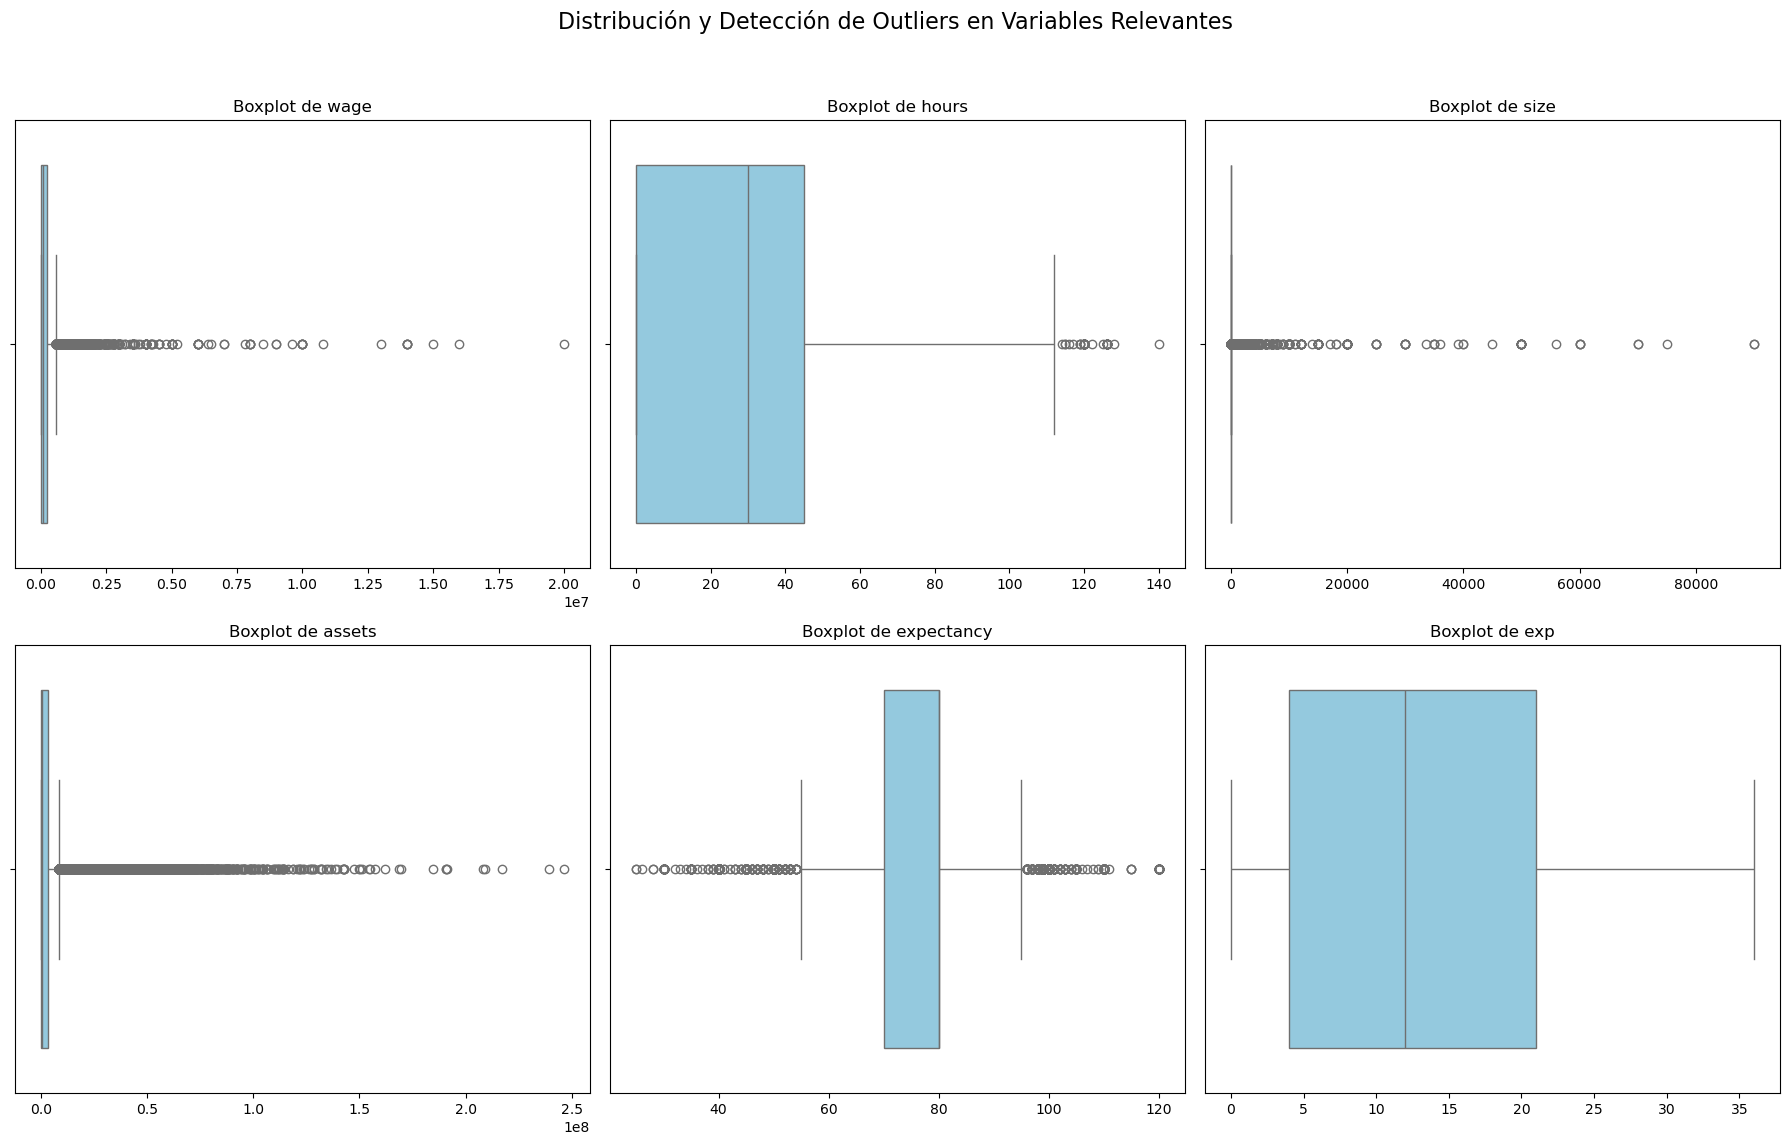

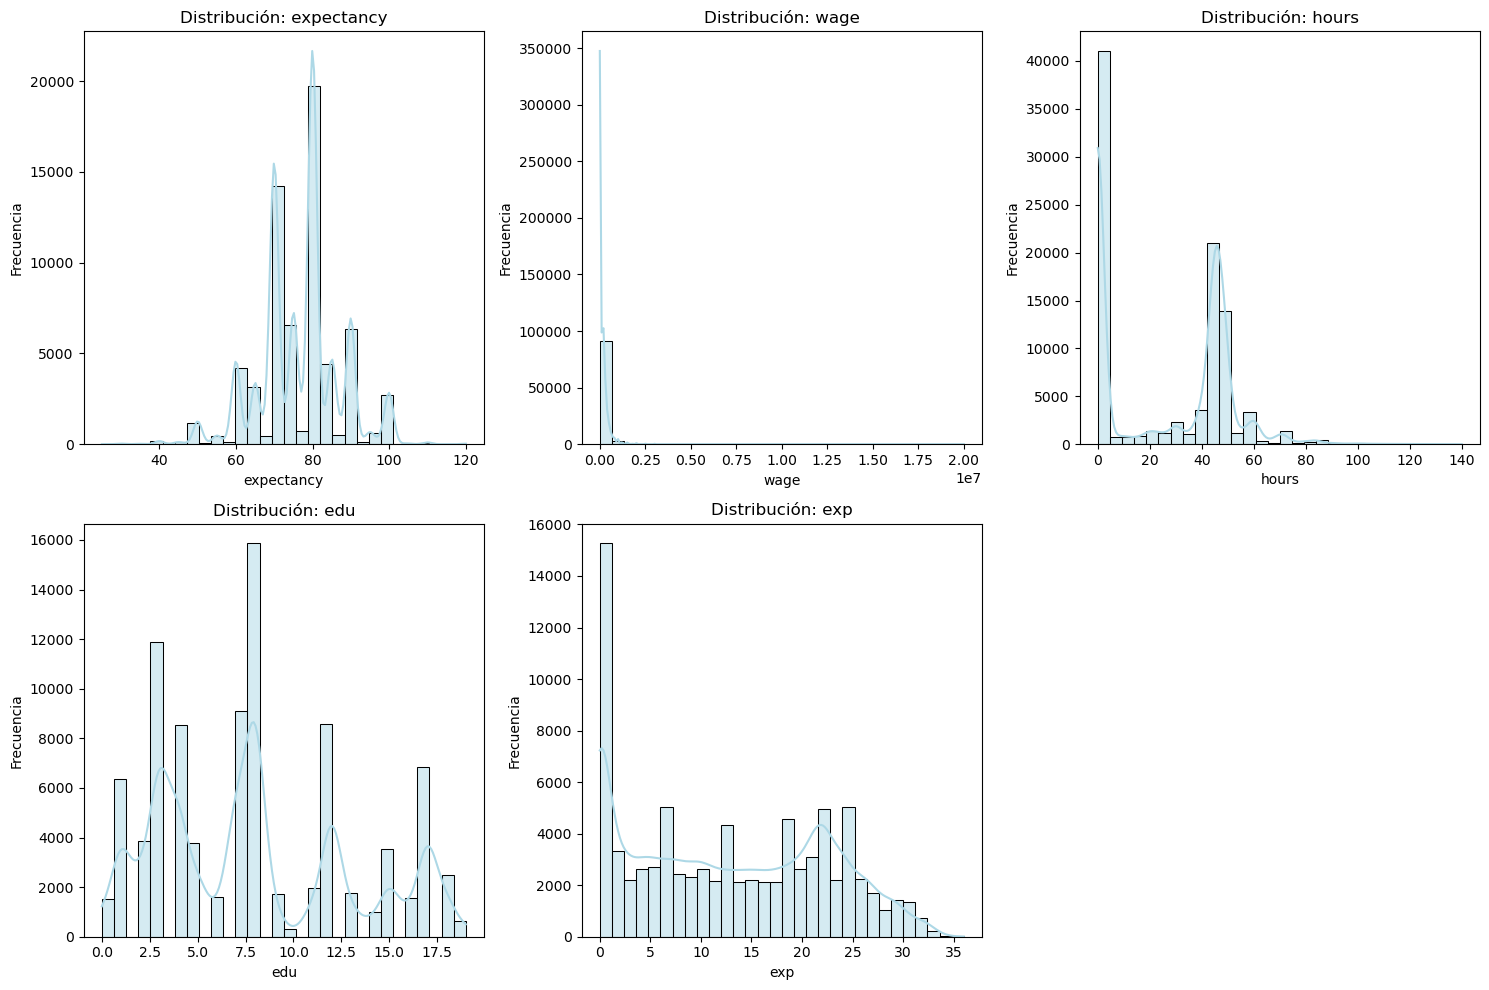

In [25]:
# === 1. Eliminar valores extremos en 'expectancy' (> 120 años) ===
num_extremos = (df['expectancy'] > 120).sum()
df['expectancy'] = np.where(df['expectancy'] > 120, np.nan, df['expectancy'])

# === 2. Reemplazar NaN por 0 en variables laborales, solo si cesante o inactivo ===
cond_inactivo_o_cesante = df['situation'].isin([2, 4])
columnas_laborales = ['wage', 'hours', 'size', 'occupation', 'informal', 'selfemp', 'publicemp']
faltantes_antes = df.loc[cond_inactivo_o_cesante, columnas_laborales].isnull().sum().sum()

for col in columnas_laborales:
    df.loc[cond_inactivo_o_cesante & df[col].isnull(), col] = 0

# === 3. Visualizar outliers en variables clave ===
vars_outliers = ['wage', 'hours', 'size', 'assets', 'expectancy', 'exp']

plt.figure(figsize=(18, 12))

for i, var in enumerate(vars_outliers):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x=df[var], color='skyblue')
    plt.title(f'Boxplot de {var}')
    plt.xlabel('')

# Título general y ajustes
plt.suptitle("Distribución y Detección de Outliers en Variables Relevantes", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
# Seleccionar variables de interés para graficar
vars_hist = ['expectancy', 'wage', 'hours', 'edu', 'exp']

# Crear los histogramas
plt.figure(figsize=(15, 10))

for i, var in enumerate(vars_hist):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[var].dropna(), bins=30, kde=True, color='lightblue')
    plt.title(f'Distribución: {var}')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [26]:
# === Eliminar valores extremos en 'expectancy' (> 120) ===
df['expectancy'] = np.where(df['expectancy'] > 120, np.nan, df['expectancy'])

# === Imputar con 0 las variables laborales para cesantes e inactivos ===
cond_inactivo_o_cesante = df['situation'].isin([2, 4])
columnas_laborales = ['wage', 'hours', 'size', 'occupation', 'informal', 'selfemp', 'publicemp']

# Calcular número de imputaciones antes de aplicar reemplazo
faltantes_antes = df.loc[cond_inactivo_o_cesante, columnas_laborales].isnull().sum().sum()

for col in columnas_laborales:
    df.loc[cond_inactivo_o_cesante & df[col].isnull(), col] = 0

# === Imputar con la mediana variables con bajo % de NA (< 5%) 
vars_bajo_na = ['cotizando', 'edu', 'status', 'hombre']
for col in vars_bajo_na:
    if df[col].isnull().sum() > 0:
        if df[col].dtype.name == 'category':
            df[col] = df[col].cat.add_categories([-1]) 
            df[col] = df[col].fillna(-1)
        else:
            df[col] = df[col].fillna(df[col].median()) 
# Columnas que siempre deben tener 0 en vez de NaN
cols_fijos = ['size', 'wage', 'hours','exp']
# Renombrar 'folio_n20' a 'ID'
df.rename(columns={'folio_n20': 'ID'}, inplace=True)
# Reemplazar NaN por 0 en esas columnas
for col in cols_fijos:
    df[col] = df[col].fillna(0)

# === Crear variables categóricas para generar dummies ===
df['yr'] = df['year'].astype('category')
df['time'] = df['time'].astype('category')
df['hombre'] = df['hombre'].astype('category')
df['status'] = df['status'].astype('category')
df['situation'] = df['situation'].astype('category')
df['kids'] = df['kids'].astype('category')
df['sistema'] = df['sistema'].astype('category')
df['cotizando'] = df['cotizando'].astype('category')  
df['illness'] = df['illness'].astype('category')    
df['cronica'] = df['cronica'].astype('category')
df['mental'] = df['mental'].astype('category')

# Crear dummies con drop_first para evitar colinealidad
df = pd.get_dummies(df, columns=['kids', 'sistema', 'cotizando', 'illness'], 
                    drop_first=True, dtype=float)

df = pd.get_dummies(df, columns=['hombre', 'status', 'situation', 'yr', 'time'], 
                    drop_first=True, dtype=float)

# === Establecer índice tipo panel: ID y year ===
df = df.set_index(['ID', 'year'])

In [27]:
# Calcular el porcentaje de NaNs por columna
porcentaje_nan = df.isna().mean() * 100

# Mostrarlo con 2 decimales
print(porcentaje_nan.round(2))

edad              0.00
edu               0.00
region           16.52
children         19.44
lmp               0.00
exp               0.00
size              0.00
occupation        6.47
wage              0.00
hours             0.00
informal         15.26
selfemp           0.55
publicemp         0.55
assets           16.61
exp_sist          0.00
expectancy       31.76
cronica          16.84
nocronica        16.84
mental           16.84
kids_1            0.00
sistema_1.0       0.00
cotizando_1.0     0.00
illness_1.0       0.00
hombre_1.0        0.00
status_2.0        0.00
status_3.0        0.00
status_4.0        0.00
status_5.0        0.00
situation_2       0.00
situation_3       0.00
situation_4       0.00
yr_4              0.00
yr_6              0.00
yr_9              0.00
yr_12             0.00
yr_15             0.00
time_2            0.00
time_3            0.00
time_4            0.00
time_5            0.00
time_6            0.00
dtype: float64


2. Ejecute un modelo Pooled OLS para estimar la relacion entre los anios de educacion y la expectativa de vida. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [29]:
y = df['expectancy']

X = df[['status_2.0', 'status_3.0', 'status_4.0', 'status_5.0', 'edu', 'cotizando_1.0',
        'cronica', 'mental', 'illness_1.0', 'kids_1','time_2',
       'time_3', 'time_4', 'situation_2',
       'situation_3','situation_4','size','wage'
       ]]

X = sm.add_constant(X)

model = lmp.PanelOLS(y, X)
mco = model.fit()
print(mco.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0433
Estimator:                   PanelOLS   R-squared (Between):              0.0646
No. Observations:               66090   R-squared (Within):               0.0024
Date:                Tue, May 20 2025   R-squared (Overall):              0.0433
Time:                        20:29:56   Log-likelihood                -2.483e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      166.14
Entities:                       25791   P-value                           0.0000
Avg Obs:                       2.5625   Distribution:                F(18,66071)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             166.14
                            

In [30]:
print(df.columns)

Index(['edad', 'edu', 'region', 'children', 'lmp', 'exp', 'size', 'occupation',
       'wage', 'hours', 'informal', 'selfemp', 'publicemp', 'assets',
       'exp_sist', 'expectancy', 'cronica', 'nocronica', 'mental', 'kids_1',
       'sistema_1.0', 'cotizando_1.0', 'illness_1.0', 'hombre_1.0',
       'status_2.0', 'status_3.0', 'status_4.0', 'status_5.0', 'situation_2',
       'situation_3', 'situation_4', 'yr_4', 'yr_6', 'yr_9', 'yr_12', 'yr_15',
       'time_2', 'time_3', 'time_4', 'time_5', 'time_6'],
      dtype='object')


3. Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [32]:
# Variable dependiente
y = df['expectancy']
# Variables explicativas

X = df[['status_2.0', 'status_3.0', 'status_4.0', 'status_5.0', 'edu', 'cotizando_1.0',
        'cronica', 'mental', 'illness_1.0', 'kids_1','time_2',
       'time_3', 'time_4', 'situation_2',
       'situation_3','situation_4','size','wage'
       ]]

# Agregar constante
X = sm.add_constant(X)
# Estimar modelo con efectos fijos (Fixed Effects)
model = lmp.PanelOLS(y, X, entity_effects=True)
fe = model.fit(cov_type="robust")
print(fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0157
Estimator:                   PanelOLS   R-squared (Between):              0.0171
No. Observations:               66090   R-squared (Within):               0.0157
Date:                Tue, May 20 2025   R-squared (Overall):              0.0219
Time:                        20:29:57   Log-likelihood                -2.196e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      35.759
Entities:                       25791   P-value                           0.0000
Avg Obs:                       2.5625   Distribution:                F(18,40281)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             30.061
                            

4. Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. 

In [34]:
# Variable dependiente
y = df['expectancy']

# Variables explicativas

X = df[['status_2.0', 'status_3.0', 'status_4.0', 'status_5.0', 'edu', 'cotizando_1.0',
        'cronica', 'mental', 'illness_1.0', 'kids_1','time_2',
       'time_3', 'time_4', 'situation_2',
       'situation_3','situation_4','size','wage'
       ]]
# Agregar constante
X = sm.add_constant(X)

# Estimar modelo de efectos aleatorios
model = lmp.RandomEffects(y, X)
re = model.fit(cov_type="robust")

# Mostrar resultados
print(re)
re.variance_decomposition

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.4139
Estimator:              RandomEffects   R-squared (Between):              0.0595
No. Observations:               66090   R-squared (Within):               0.0085
Date:                Tue, May 20 2025   R-squared (Overall):              0.0420
Time:                        20:29:57   Log-likelihood                -2.362e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      2592.3
Entities:                       25791   P-value                           0.0000
Avg Obs:                       2.5625   Distribution:                F(18,66071)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             118.92
                            

Effects                   33.132376
Residual                  73.845717
Percent due to Effects     0.309712
Name: Variance Decomposition, dtype: float64


5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

In [36]:
# === Comparación lado a lado ===
print(lmp.compare({"FE": fe, "RE": re, "Pooled": mco}))

# === Hausman Test ===
import numpy.linalg as la
from scipy import stats

def hausman(fe, re):
 diff = fe.params-re.params
 psi = fe.cov - re.cov
 dof = diff.size -1
 W = diff.dot(la.inv(psi)).dot(diff)
 pval = stats.chi2.sf(W, dof)
 return W, dof, pval
# Ejecutar test
htest = hausman(fe, re) 
print("Hausman Test: chi-2 = {0}, df = {1}, p-value = {2}".format(htest[0], htest[1], htest[2]))

                            Model Comparison                           
                                    FE                RE         Pooled
-----------------------------------------------------------------------
Dep. Variable               expectancy        expectancy     expectancy
Estimator                     PanelOLS     RandomEffects       PanelOLS
No. Observations                 66090             66090          66090
Cov. Est.                       Robust            Robust     Unadjusted
R-squared                       0.0157            0.4139         0.0433
R-Squared (Within)              0.0157            0.0085         0.0024
R-Squared (Between)             0.0171            0.0595         0.0646
R-Squared (Overall)             0.0219            0.0420         0.0433
F-statistic                     35.759            2592.3         166.14
P-value (F-stat)                0.0000            0.0000         0.0000
=====================     ============   ===============   =====

6. Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

In [39]:
# 1. Variables explicativas

X = df[['status_2.0', 'status_3.0', 'status_4.0', 'status_5.0', 'edu', 'cotizando_1.0',
        'cronica', 'mental', 'illness_1.0', 'kids_1','time_2',
       'time_3', 'time_4', 'situation_2',
       'situation_3','situation_4','size','wage'
       ]]
# 2. Convertir todo a tipo numérico 
X = X.astype(float)

# 3. Crear promedios por ID
Xm = X.groupby('ID').transform('mean')
Xm.columns = ['m' + col for col in Xm.columns]

# 4. Combinar X original + promedios
Xc = pd.concat([df, Xm], axis=1)

# 5. Variable dependiente
y = Xc['expectancy']

# 6. Definir matriz X completa
X = Xc[['status_2.0', 'status_3.0', 'status_4.0', 'status_5.0', 'edu', 'cotizando_1.0',
        'cronica', 'mental', 'illness_1.0', 'kids_1', 'time_2', 'time_3', 'time_4',
        'situation_2', 'situation_3', 'situation_4', 'size', 'wage',
        'mstatus_2.0', 'mstatus_3.0', 'mstatus_4.0', 'mstatus_5.0', 'medu', 'mcotizando_1.0',
        'mcronica', 'mmental', 'millness_1.0', 'mkids_1', 'msituation_2', 'msituation_3',
        'msituation_4', 'msize', 'mwage']]

# 7. Agregar constante
X = sm.add_constant(X)

# 8. Estimar modelo CRE (efectos aleatorios con medias entre)
model = lmp.RandomEffects(y, X)
cre = model.fit(cov_type='robust')

# 9. Mostrar resultados
print(cre)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.4008
Estimator:              RandomEffects   R-squared (Between):              0.0681
No. Observations:               64938   R-squared (Within):               0.0154
Date:                Tue, May 20 2025   R-squared (Overall):              0.0520
Time:                        20:29:58   Log-likelihood                -2.318e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1315.7
Entities:                       24639   P-value                           0.0000
Avg Obs:                       2.6356   Distribution:                F(33,64904)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             81.488
                            

7. Usando el modelo CRE, prediga la distribucion del componente no observado. Que puede inferir respecto de la heterogeneidad fija en el tiempo y su impacto en la expectativa de vida?

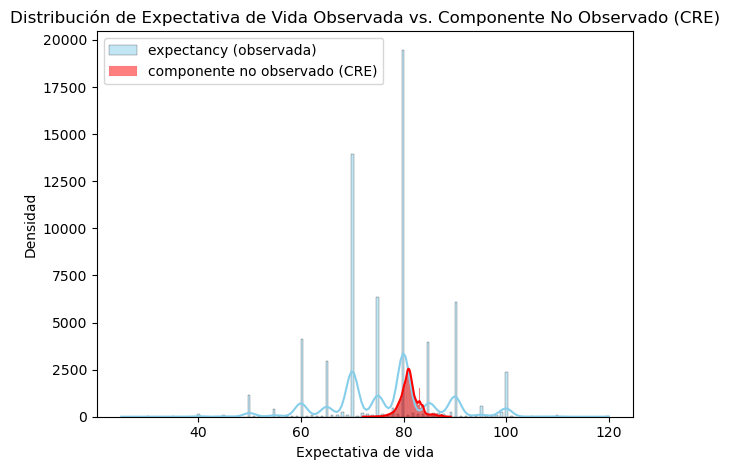

In [41]:
# 1. Crear una copia de X y anular las variables que varían con el tiempo
Xpred = X.copy()
variables_dentro = ['status_2.0', 'status_3.0', 'status_4.0', 'status_5.0', 'edu', 'cotizando_1.0',
        'cronica', 'mental', 'illness_1.0', 'kids_1','time_2',
       'time_3', 'time_4', 'situation_2',
       'situation_3','situation_4','size','wage'
       ]
X = df
for var in variables_dentro:
    if var in Xpred.columns:
        Xpred[var] = 0

# 2. Predecir la parte explicada por efectos entre individuos (componente no observado)
yhat = cre.predict(Xpred)

# 3. Graficar comparación entre y observada y componente no observado

sns.histplot(data=y, color="skyblue", label="expectancy (observada)", kde=True)
sns.histplot(data=yhat.predictions, color="red", label="componente no observado (CRE)", kde=True)

plt.title("Distribución de Expectativa de Vida Observada vs. Componente No Observado (CRE)")
plt.xlabel("Expectativa de vida")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.show()

8. Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las variables explicativas sobre la expectativa de vida?

In [43]:
# 1. Pooled OLS
y_pooled = df['expectancy']
X_pooled=df[['status_2.0', 'status_3.0', 'status_4.0', 'status_5.0', 'edu', 'cotizando_1.0',
        'cronica', 'mental', 'illness_1.0', 'kids_1','time_2',
       'time_3', 'time_4', 'situation_2',
       'situation_3','situation_4','size','wage'
       ]]
X_pooled = sm.add_constant(X_pooled)
pooled = lmp.PanelOLS(y_pooled, X_pooled)
mco = pooled.fit()

# 2. Efectos Fijos (FE)
fe_model = lmp.PanelOLS(y_pooled, X_pooled, entity_effects=True)
fe = fe_model.fit(cov_type="robust")

# 3. Efectos Aleatorios (RE)
re_model = lmp.RandomEffects(y_pooled, X_pooled)
re = re_model.fit(cov_type="robust")

# 4. CRE: agregar variables mX

X_cre = df[['status_2.0', 'status_3.0', 'status_4.0', 'status_5.0', 'edu', 'cotizando_1.0',
        'cronica', 'mental', 'illness_1.0', 'kids_1','time_2',
       'time_3', 'time_4', 'situation_2',
       'situation_3','situation_4','size','wage'
       ]].astype(float)

Xm = X_cre.groupby(df.index.get_level_values('ID')).transform('mean')
Xm.columns = ['m' + col for col in Xm.columns]

X_cre_full = pd.concat([X_cre, Xm], axis=1)
X_cre_full = sm.add_constant(X_cre_full)
cre_model = lmp.RandomEffects(y_pooled, X_cre_full)
cre = cre_model.fit(cov_type='robust')
# 5. Comparar todos los modelos
print(lmp.compare({"Pooled": mco, "FE": fe, "RE": re, "CRE": cre}))

                                     Model Comparison                                    
                                Pooled             FE                RE               CRE
-----------------------------------------------------------------------------------------
Dep. Variable               expectancy     expectancy        expectancy        expectancy
Estimator                     PanelOLS       PanelOLS     RandomEffects     RandomEffects
No. Observations                 66090          66090             66090             50078
Cov. Est.                   Unadjusted         Robust            Robust            Robust
R-squared                       0.0433         0.0157            0.4139            0.4137
R-Squared (Within)              0.0024         0.0157            0.0085            0.0283
R-Squared (Between)             0.0646         0.0171            0.0595            0.0573
R-Squared (Overall)             0.0433         0.0219            0.0420            0.0505
F-statisti